In [49]:
import pandas as pd
import numpy as np
df = pd.read_csv('Darknet.csv')

print("Original dataset shape:", df.shape)
print("\nColumns:\n", df.columns.tolist())
print("\n Missing values:\n", df.isnull().sum().sum())


Original dataset shape: (158616, 85)

Columns:
 ['Flow ID', 'Src IP', 'Src Port', 'Dst IP', 'Dst Port', 'Protocol', 'Timestamp', 'Flow Duration', 'Total Fwd Packet', 'Total Bwd packets', 'Total Length of Fwd Packet', 'Total Length of Bwd Packet', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Packet Length Std', 'Bwd Packet Length Max', 'Bwd Packet Length Min', 'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length', 'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s', 'Packet Length Min', 'Packet Length Max', 'Packet Length Mean', 'Packet Length Std', 'Packet Length Variance', 'FIN Flag Count', 'SYN Flag Count', 'RST 

In [2]:
cols_to_drop=['Flow ID','Src IP','Dst IP','Timestamp']
df = df.drop(columns=[c for c in cols_to_drop if c in df.columns], errors='ignore')
print(df.columns.tolist())

['Src Port', 'Dst Port', 'Protocol', 'Flow Duration', 'Total Fwd Packet', 'Total Bwd packets', 'Total Length of Fwd Packet', 'Total Length of Bwd Packet', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Packet Length Std', 'Bwd Packet Length Max', 'Bwd Packet Length Min', 'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length', 'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s', 'Packet Length Min', 'Packet Length Max', 'Packet Length Mean', 'Packet Length Std', 'Packet Length Variance', 'FIN Flag Count', 'SYN Flag Count', 'RST Flag Count', 'PSH Flag Count', 'ACK Flag Count', 'URG Flag Count', 'CWE Flag Count', 'ECE Fl

In [3]:
df.replace([np.inf,-np.inf],np.nan,inplace=True)
df.dropna(inplace=True)

In [4]:
for col in df.select_dtypes(include=['object']).columns:
    if col != 'Label':
        df[col] = df[col].astype('category').cat.codes

In [5]:
df['Label'] = df['Label'].replace({
    'BENIGN': 0,
    'Benign': 0,
    'Normal': 0,
    'Malicious': 1,
    'Attack': 1,
    'DDoS': 1,
    'Botnet': 1
})

In [6]:
print(df.shape)
print(df.columns.tolist())

(158566, 81)
['Src Port', 'Dst Port', 'Protocol', 'Flow Duration', 'Total Fwd Packet', 'Total Bwd packets', 'Total Length of Fwd Packet', 'Total Length of Bwd Packet', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Packet Length Std', 'Bwd Packet Length Max', 'Bwd Packet Length Min', 'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length', 'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s', 'Packet Length Min', 'Packet Length Max', 'Packet Length Mean', 'Packet Length Std', 'Packet Length Variance', 'FIN Flag Count', 'SYN Flag Count', 'RST Flag Count', 'PSH Flag Count', 'ACK Flag Count', 'URG Flag Count', 'CWE Flag Co

In [7]:
df.drop_duplicates(inplace=True)


In [ ]:
from scipy import stats
import numpy as np

numeric_df = df.select_dtypes(include=[np.number])
z = np.abs(stats.zscore(numeric_df))

outlier_rows = (z > 3).any(axis=1)
print("Outlier rows:", outlier_rows.sum(), "out of", len(df))


Outlier rows: 37277 out of 119527


In [9]:

from scipy import stats
import numpy as np

numeric_df = df.select_dtypes(include=[np.number])
z = np.abs(stats.zscore(numeric_df))

threshold = 0.2 * numeric_df.shape[1]

outlier_counts = (z > 3).sum(axis=1)

df_filtered = df[outlier_counts < threshold]

print("Before removing:", df.shape)
print("After removing:", df_filtered.shape)


Before removing: (119527, 81)
After removing: (119395, 81)


In [10]:
df = df_filtered.copy()
df.reset_index(drop=True, inplace=True)


In [11]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df.drop('Label', axis=1))
y = df['Label']


In [12]:
df.shape

(119395, 81)

In [13]:
df.to_csv("Cleaned_Darknet.csv", index=False)

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
df = pd.read_csv('Cleaned_Darknet.csv')

In [15]:
X = df.drop('Label',axis=1)
Y = df['Label']

In [16]:
print(df.shape)

(119395, 81)


In [17]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [18]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, Y, test_size=0.2, random_state=42, stratify=Y)

In [19]:
print("Training set:", X_train.shape, y_train.shape)
print("Testing set:", X_test.shape, y_test.shape)

Training set: (95516, 80) (95516,)
Testing set: (23879, 80) (23879,)


In [20]:
import numpy as np
np.savez("Darknet_split_data.npz", X_train=X_train, X_test=X_test, y_train=y_train, y_test=y_test)

In [21]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [22]:
data = np.load("Darknet_split_data.npz",allow_pickle=True)
X_train, X_test, y_train, y_test = data['X_train'], data['X_test'], data['y_train'], data['y_test']

In [23]:
X_train = X_train.reshape((X_train.shape[0], 1, X_train.shape[1]))
X_test = X_test.reshape((X_test.shape[0], 1, X_test.shape[1]))

print("✅ Data reshaped for LSTM:")
print("X_train:", X_train.shape, "X_test:", X_test.shape)

✅ Data reshaped for LSTM:
X_train: (95516, 1, 80) X_test: (23879, 1, 80)


In [24]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
model = Sequential([
    LSTM(64, input_shape=(X_train.shape[1], X_train.shape[2]), return_sequences=False),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)


c:\Users\mohit yadav\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [25]:
print(X_train.dtype, y_train.dtype)
print(np.unique(y_train))


float64 object
['Non-Tor' 'NonVPN' 'Tor' 'VPN']


In [26]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

y_train = encoder.fit_transform(y_train)
y_test = encoder.transform(y_test)

y_train = y_train.astype(np.int32)
y_test = y_test.astype(np.int32)

print("✅ Labels encoded successfully.")
print("Unique encoded labels:", np.unique(y_train))


✅ Labels encoded successfully.
Unique encoded labels: [0 1 2 3]


In [27]:
import numpy as np
print(np.unique(y_train))


[0 1 2 3]


In [28]:
y_train = np.where(y_train == 'VPN', 1, 0)
y_test = np.where(y_test == 'VPN', 1, 0)


In [29]:
y_train = np.where(y_train == 'VPN', 1, 0)
y_test = np.where(y_test == 'VPN', 1, 0)

In [30]:
print(np.unique(y_train))
print(y_train[:10])


[0]
[0 0 0 0 0 0 0 0 0 0]


In [31]:
import numpy as np

X_train = np.expand_dims(X_train, axis=2)
X_test = np.expand_dims(X_test, axis=2)

print("New X_train shape:", X_train.shape)


New X_train shape: (95516, 1, 1, 80)


In [32]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, LSTM, Dense, Dropout

X_train = np.expand_dims(X_train, axis=2)
X_test = np.expand_dims(X_test, axis=2)

model = Sequential([
    Conv1D(filters=64, kernel_size=1, activation='relu', input_shape=(X_train.shape[1], 1)),
    MaxPooling1D(pool_size=2),
    Dropout(0.3),

    LSTM(64, return_sequences=False),
    Dropout(0.3),

    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()


c:\Users\mohit yadav\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 1, 64)          │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 0, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 0, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 37,377 (146.00 KB)

 Trainable params: 37,377 (146.00 KB)

 Non-trainable params: 0 (0.00 B)

In [33]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, LSTM, Dense, Dropout, Flatten, Input, Attention, Bidirectional
from tensorflow.keras.models import Model
import tensorflow as tf


In [34]:
from tensorflow.keras.layers import Layer
import tensorflow.keras.backend as K

class AttentionLayer(Layer):
    def __init__(self, **kwargs):
        super(AttentionLayer, self).__init__(**kwargs)

    def build(self, input_shape):
        self.W = self.add_weight(name="att_weight", shape=(input_shape[-1], 1),
                                 initializer="normal")
        self.b = self.add_weight(name="att_bias", shape=(input_shape[1], 1),
                                 initializer="zeros")        
        super(AttentionLayer, self).build(input_shape)

    def call(self, x):
        e = K.tanh(K.dot(x, self.W) + self.b)
        a = K.softmax(e, axis=1)
        output = x * a
        return K.sum(output, axis=1)


In [35]:
from tensorflow.keras.layers import Input
from tensorflow.keras.models import Model

input_layer = Input(shape=(X_train.shape[1], 1))

cnn = Conv1D(64, kernel_size=1, activation='relu')(input_layer)
cnn = MaxPooling1D(pool_size=2)(cnn)
cnn = Dropout(0.3)(cnn)

lstm_out = LSTM(64, return_sequences=True)(cnn)  

attention_out = AttentionLayer()(lstm_out)

dense = Dense(64, activation='relu')(attention_out)
dense = Dropout(0.3)(dense)
output = Dense(1, activation='sigmoid')(dense)

model = Model(inputs=input_layer, outputs=output)
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

model.summary()


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 1, 1)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 1, 64)          │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 0, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 0, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 0, 64)          │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ attention_layer                 │ (None, 64)             │            64 │
│ (AttentionLayer)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 37,441 (146.25 KB)

 Trainable params: 37,441 (146.25 KB)

 Non-trainable params: 0 (0.00 B)

In [36]:
lstm_out = Bidirectional(LSTM(64, return_sequences=True))(cnn)


In [37]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weights = dict(enumerate(class_weights))

In [38]:
from tensorflow.keras.layers import Dropout

In [39]:
model = Sequential()
model.add(Dense(64, activation='relu'))

In [40]:
from tensorflow.keras import regularizers

Dense(64, activation='relu', kernel_regularizer=regularizers.l2(0.001))

<Dense name=dense_7, built=False>

In [41]:
from tensorflow.keras.layers import BatchNormalization

model.add(BatchNormalization())

In [42]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)


In [43]:
X_train_noisy = X_train + np.random.normal(0, 0.01, X_train.shape)


In [44]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])


In [ ]:

import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.utils.class_weight import compute_class_weight

_data = np.load("Darknet_split_data.npz", allow_pickle=True)
X_train = _data['X_train']
X_test = _data['X_test']
y_train_raw = _data['y_train']
y_test_raw = _data['y_test']

y_train = (y_train_raw == 'VPN').astype(np.float32).reshape(-1, 1)
y_test = (y_test_raw == 'VPN').astype(np.float32).reshape(-1, 1)

X_train = X_train.reshape((X_train.shape[0], 1, X_train.shape[1]))
X_test = X_test.reshape((X_test.shape[0], 1, X_test.shape[1]))

print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("X_test:", X_test.shape, "y_test:", y_test.shape)
print("y_train classes:", np.unique(y_train))

classes = np.array([0., 1.], dtype=np.float32)
class_weights_values = compute_class_weight(class_weight='balanced', classes=classes, y=y_train.flatten())
class_weights = {int(c): float(w) for c, w in zip(classes, class_weights_values)}
print("Class weights:", class_weights)

model = Sequential([
    Input(shape=(X_train.shape[1], X_train.shape[2])),
    LSTM(64, return_sequences=False),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=10,
    batch_size=64,
    callbacks=[early_stop],
    class_weight=class_weights,
    verbose=1
)


X_train: (95516, 1, 80) y_train: (95516, 1)
X_test: (23879, 1, 80) y_test: (23879, 1)
y_train classes: [0. 1.]
Class weights: {0: 0.6187551824212272, 1: 2.605171285184377}
Epoch 1/10
1493/1493 ━━━━━━━━━━━━━━━━━━━━ 14s 6ms/step - accuracy: 0.8948 - loss: 0.2563 - val_accuracy: 0.9188 - val_loss: 0.1970
Epoch 2/10
1493/1493 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9259 - loss: 0.1691 - val_accuracy: 0.9327 - val_loss: 0.1608
Epoch 3/10
1493/1493 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9307 - loss: 0.1520 - val_accuracy: 0.9281 - val_loss: 0.1621
Epoch 4/10
1493/1493 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9335 - loss: 0.1417 - val_accuracy: 0.9344 - val_loss: 0.1406
Epoch 5/10
1493/1493 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9369 - loss: 0.1325 - val_accuracy: 0.9397 - val_loss: 0.1404
Epoch 6/10
1493/1493 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9392 - loss: 0.1283 - val_accuracy: 0.9423 - val_loss: 0.1284
Epoch 7/10
1493/1493 ━━━━━━━━━━━━━━━━━━━━ 2s 

In [46]:

import json
from datetime import datetime

model_path = f"vpn_binary_lstm_{datetime.now().strftime('%Y%m%d_%H%M%S')}.keras"
model.save(model_path)
print("Saved model to:", model_path)

meta = {
    "model_path": model_path,
    "input_shape": tuple(X_train.shape[1:]),
    "threshold": 0.5,
    "label_mapping": {"non-VPN": 0, "VPN": 1},
}
with open(model_path.replace('.keras', '_meta.json'), 'w') as f:
    json.dump(meta, f, indent=2)
print("Saved meta:", model_path.replace('.keras', '_meta.json'))

def predict_vpn_prob(scaled_feature_vector_80):
    arr = np.asarray(scaled_feature_vector_80, dtype=np.float32).reshape(1, 1, -1)
    prob = float(model.predict(arr, verbose=0)[0][0])
    return prob


Saved model to: vpn_binary_lstm_20260201_112709.keras
Saved meta: vpn_binary_lstm_20260201_112709_meta.json


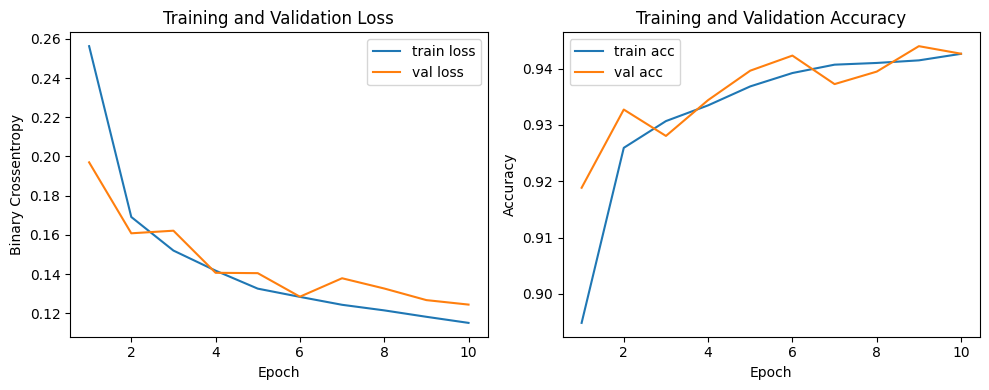

In [47]:

import matplotlib.pyplot as plt

if 'history' in globals() and hasattr(history, 'history'):
    hist = history.history
    epochs = range(1, len(hist.get('loss', [])) + 1)

    plt.figure(figsize=(10,4))

    plt.subplot(1,2,1)
    plt.plot(epochs, hist.get('loss', []), label='train loss')
    if 'val_loss' in hist:
        plt.plot(epochs, hist['val_loss'], label='val loss')
    plt.xlabel('Epoch')
    plt.ylabel('Binary Crossentropy')
    plt.title('Training and Validation Loss')
    plt.legend()

    plt.subplot(1,2,2)
    plt.plot(epochs, hist.get('accuracy', []), label='train acc')
    if 'val_accuracy' in hist:
        plt.plot(epochs, hist['val_accuracy'], label='val acc')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.title('Training and Validation Accuracy')
    plt.legend()

    plt.tight_layout()
    plt.show()
else:
    print("history not found. Please run the training cell first to create the history object.")